# Empirical study notebook

In [1]:
from decision_maker import *
from explainer import estimate_interventional_probability_tabular, PrototypeTabularExplainer
from fairlearn.datasets import fetch_acs_income, fetch_adult
import graphviz
from IPython.display import Image, display
import lime
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from utils import *
from xgboost import XGBClassifier

RANDOM_SEED = 42

/home/alexis/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loan Approval dataset

In [2]:
# Loan Approval dataset
loan_df = pd.read_csv("./LoanApproval.csv")
loan_df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [3]:
X_loan = loan_df.drop(columns=["loan_status"])
y_loan = loan_df["loan_status"]

loan_features = X_loan.columns.to_list()
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(X_loan, y_loan, test_size=0.2, random_state=RANDOM_SEED)

categorical_cols = X_loan.select_dtypes(include=['object']).columns.tolist()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor_loan = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)], remainder='passthrough')

X_train_processed_loan = pd.DataFrame(preprocessor_loan.fit_transform(X_train_loan), columns=loan_features, index=X_train_loan.index)
X_test_processed_loan = pd.DataFrame(preprocessor_loan.transform(X_test_loan), columns=loan_features, index=X_test_loan.index)

loan_model1 = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
loan_model1.fit(X_train_processed_loan, y_train_loan)
y_predict_loan = loan_model1.predict(X_test_processed_loan)

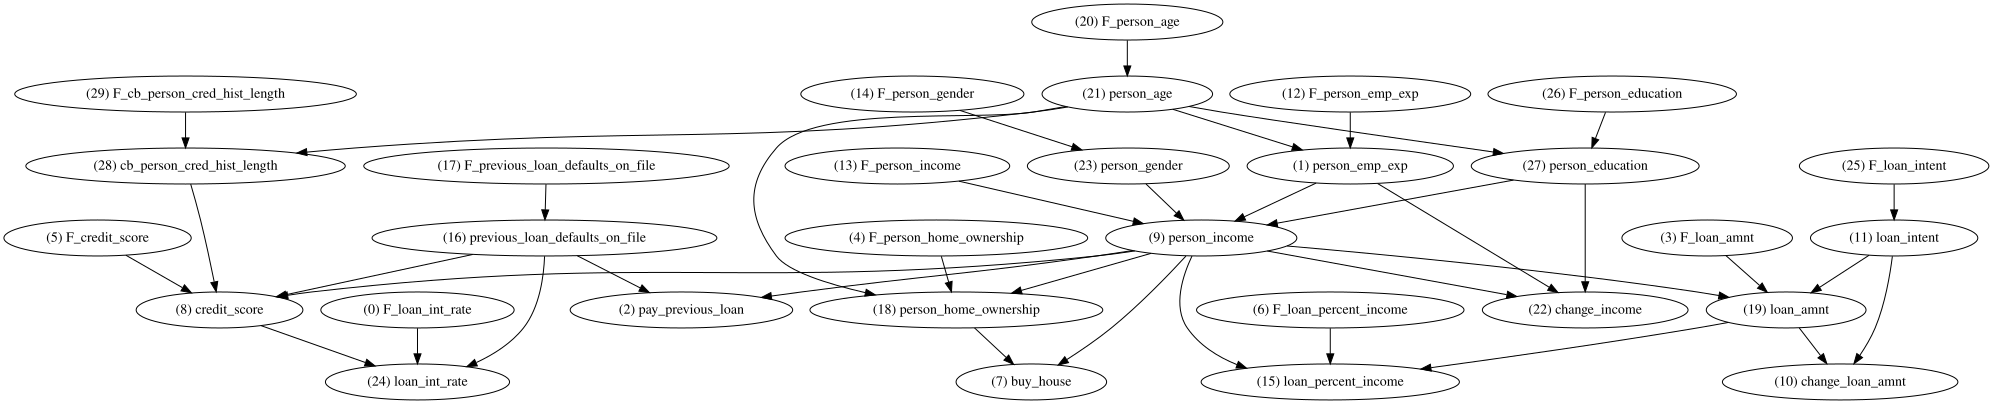

In [4]:
loan_actions = [
    "buy_house",
    "change_loan_amnt", 
    "change_income", 
    "pay_previous_loan"
]

loan_causal = CausalModel(features=loan_features, actions=loan_actions)

loan_causal.add_causal_edge("person_age", "person_emp_exp")
loan_causal.add_causal_edge("person_age", "cb_person_cred_hist_length")
loan_causal.add_causal_edge("person_age", "person_education")

loan_causal.add_causal_edge("person_education", "person_income")
loan_causal.add_causal_edge("person_emp_exp", "person_income")

loan_causal.add_causal_edge("person_income", "person_home_ownership")
loan_causal.add_causal_edge("person_age", "person_home_ownership")

loan_causal.add_causal_edge("cb_person_cred_hist_length", "credit_score")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "credit_score")
loan_causal.add_causal_edge("person_income", "credit_score")

loan_causal.add_causal_edge("loan_intent", "loan_amnt")
loan_causal.add_causal_edge("person_income", "loan_amnt")

loan_causal.add_causal_edge("loan_amnt", "loan_percent_income")
loan_causal.add_causal_edge("person_income", "loan_percent_income")

loan_causal.add_causal_edge("credit_score", "loan_int_rate")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "loan_int_rate")
#loan_causal.add_causal_edge("loan_percent_income", "loan_int_rate")
#loan_causal.add_causal_edge("person_home_ownership", "loan_int_rate")

loan_causal.add_causal_edge("person_gender", "person_income")

loan_causal.add_causal_edge("person_income", "buy_house")
loan_causal.add_causal_edge("person_home_ownership", "buy_house")

loan_causal.add_causal_edge("loan_amnt", "change_loan_amnt")
loan_causal.add_causal_edge("loan_intent", "change_loan_amnt")

loan_causal.add_causal_edge("person_income", "change_income")
loan_causal.add_causal_edge("person_education", "change_income")
loan_causal.add_causal_edge("person_emp_exp", "change_income")

loan_causal.add_causal_edge("previous_loan_defaults_on_file", "pay_previous_loan")
loan_causal.add_causal_edge("person_income", "pay_previous_loan")

dag = loan_causal.getDAG()
loan_dot = dag.toDot()
loan_graph = graphviz.Source(loan_dot)
display(loan_graph)

In [5]:
utility_matrix = np.array([[-12, 0], [-7, 0], [-12, 0], [-6, 0]])
prototype_explainer = PrototypeTabularExplainer(loan_model1, X_train_processed_loan, loan_features, loan_actions, loan_causal, utility_matrix, cognitive=())
x_instance = X_test_processed_loan.iloc[[0]]

In [6]:
prototype_explainer.explain_instance(x_instance)
loan_model1_explanations = pd.DataFrame(prototype_explainer.extract_explanation())
display(loan_model1_explanations)

,features,prediction probability,utility score,preferrable action,information score
0,{'person_home_ownership'},"[0.7329098768834578, 0.2670901231165461]",-4.397459,pay_previous_loan,0.580343
1,"{'person_home_ownership', 'loan_int_rate'}","[0.7443560687421075, 0.2556439312578997]",-4.466136,pay_previous_loan,0.568451
2,{'loan_int_rate'},"[0.7450707747371473, 0.2549292252628573]",-4.470425,pay_previous_loan,0.567686
3,"{'person_home_ownership', 'loan_percent_income'}","[0.8208446315718143, 0.17915536842818183]",-4.925068,pay_previous_loan,0.470110
4,{'loan_percent_income'},"[0.8227592877731847, 0.1772407122268218]",-4.936556,pay_previous_loan,0.467184
5,"{'person_home_ownership', 'loan_percent_income...","[0.8337975329317087, 0.16620246706828906]",-5.002785,pay_previous_loan,0.449813
6,"{'loan_percent_income', 'loan_int_rate'}","[0.8358476689730484, 0.16415233102695512]",-5.015086,pay_previous_loan,0.446492


In [7]:
loan_model1_attribution = pd.DataFrame(prototype_explainer.extract_attribution(x_instance))
display(loan_model1_attribution)

,features,prediction probability,utility score,preferrable action,information score
0,person_home_ownership,"[0.7329098768834578, 0.2670901231165461]",-4.397459,pay_previous_loan,0.580343
1,loan_int_rate,"[0.7450707747371473, 0.2549292252628573]",-4.470425,pay_previous_loan,0.567686
2,loan_percent_income,"[0.8227592877731847, 0.1772407122268218]",-4.936556,pay_previous_loan,0.467184
3,previous_loan_defaults_on_file,"[0.9264424915379204, 0.0735575084620796]",-5.558655,pay_previous_loan,0.262745
4,person_age,"[0.9264424915379204, 0.07355750846207962]",-5.558655,pay_previous_loan,0.262745
5,person_gender,"[0.9264424915379204, 0.07355750846207962]",-5.558655,pay_previous_loan,0.262745
6,person_education,"[0.9264424915379204, 0.07355750846207962]",-5.558655,pay_previous_loan,0.262745
7,person_income,"[0.9264424915379204, 0.07355750846207962]",-5.558655,pay_previous_loan,0.262745
8,person_emp_exp,"[0.9264424915379204, 0.07355750846207962]",-5.558655,pay_previous_loan,0.262745
9,loan_amnt,"[0.9264424915379204, 0.07355750846207962]",-5.558655,pay_previous_loan,0.262745


### Empirical comparison

In [8]:
dynamic_class_names = [str(c) for c in sorted(loan_df['loan_status'].unique())]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed_loan.values,
    feature_names=loan_features,
    class_names=dynamic_class_names, 
    mode='classification'
)

shap_explainer = shap.Explainer(loan_model1)

tester = ExplainerTester(
    model=loan_model1,
    features=loan_features,
    actions=loan_actions,
    causal_model=loan_causal,
    utility_matrix=utility_matrix,
    X_train=X_train_processed_loan,
    X_test=X_test_processed_loan,
    lime_explainer=lime_explainer,
    shap_explainer=shap_explainer,
    n_samples=20 
)

### Data consistency test

/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a v

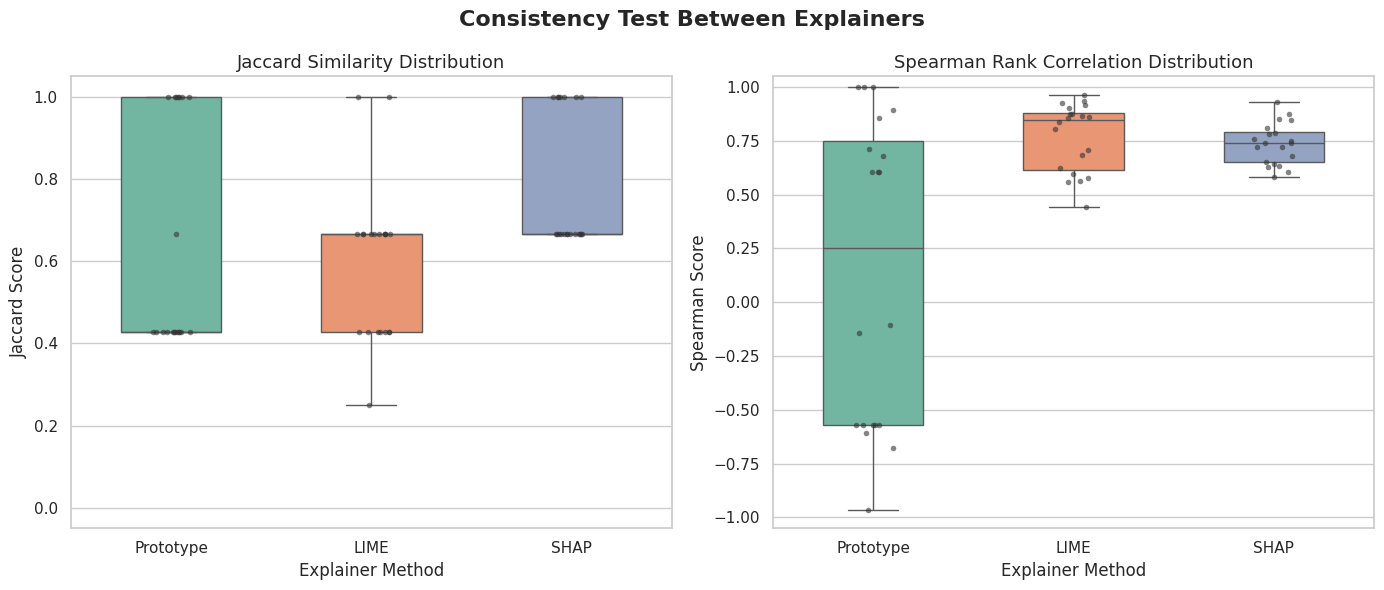

({'jaccard': [1.0,
   0.42857142857142855,
   0.42857142857142855,
   0.42857142857142855,
   0.6666666666666666,
   1.0,
   0.42857142857142855,
   1.0,
   1.0,
   0.42857142857142855,
   0.42857142857142855,
   0.42857142857142855,
   0.42857142857142855,
   1.0,
   0.42857142857142855,
   1.0,
   1.0,
   0.42857142857142855,
   0.42857142857142855,
   0.42857142857142855],
  'spearman': [0.8928571428571429,
   -0.6785714285714286,
   -0.5714285714285714,
   -0.6071428571428572,
   0.8571428571428572,
   0.7142857142857143,
   -0.9642857142857142,
   1.0,
   0.6071428571428572,
   -0.1428571428571428,
   0.6071428571428572,
   0.6071428571428572,
   -0.5714285714285714,
   1.0,
   -0.5714285714285714,
   0.6785714285714286,
   1.0,
   -0.1071428571428572,
   -0.5714285714285714,
   -0.5714285714285714]},
 {'jaccard': [0.42857142857142855,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666

In [9]:
tester.consistency_test(display=True)

### Stability test

/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a v

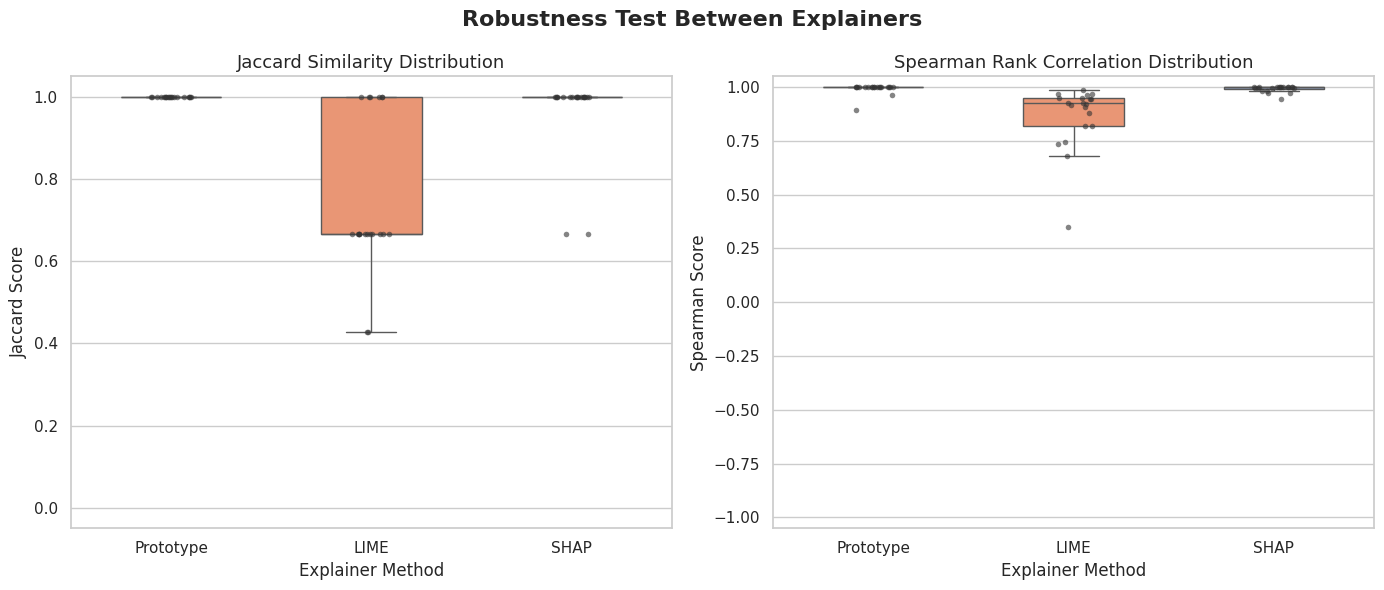

({'jaccard': [1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0],
  'spearman': [1.0,
   1.0,
   1.0,
   0.9642857142857143,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   0.8928571428571429,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0]},
 {'jaccard': [0.6666666666666666,
   0.42857142857142855,
   0.6666666666666666,
   1.0,
   1.0,
   0.42857142857142855,
   1.0,
   1.0,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   1.0,
   0.6666666666666666,
   1.0,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666],
  'spearman': [0.7454545454545455,
   0.35151515151515156,
   0.8181818181818181,
   0.9636363636363636,
   0.9454545454545454,
   0.9212121212121213,
   0.8787878787878788,
   0.9272727272727272,
   0.9272727272727272,
   0.987878787878787

In [10]:
tester.robustness_test(display=True)

/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a v

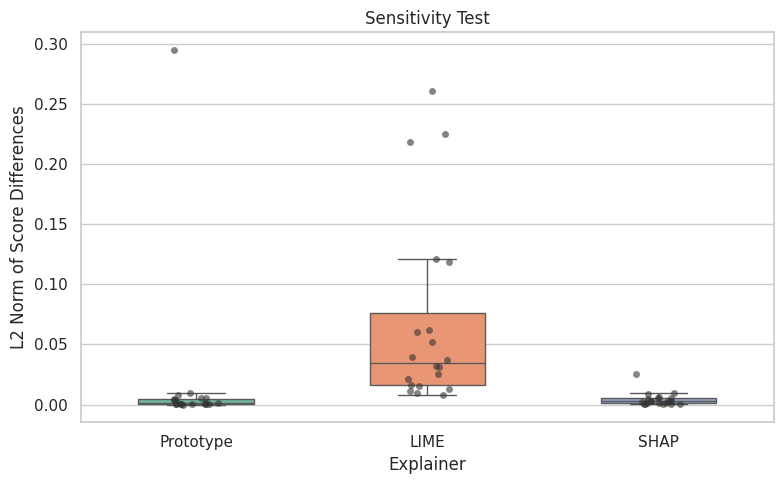

{'Prototype': [np.float64(0.0009150974867992015),
  np.float64(8.70769233763848e-05),
  np.float64(0.005421144612452366),
  np.float64(0.2951431891142399),
  np.float64(0.0058191115220664),
  np.float64(0.0007813678246929868),
  np.float64(0.0004500408592590396),
  np.float64(0.0009528682769084939),
  np.float64(0.003947219928469075),
  np.float64(0.004430228634508908),
  np.float64(0.00034182117093881916),
  np.float64(0.0040577027989308675),
  np.float64(0.00987948820569194),
  np.float64(0.0011632118070128963),
  np.float64(0.0),
  np.float64(0.007961018870927762),
  np.float64(0.0005796137853605474),
  np.float64(0.00020271313632454088),
  np.float64(0.00022079019121768988),
  np.float64(0.00021806898251408317)],
 'LIME': [np.float64(0.06069113829608847),
  np.float64(0.016463182690802228),
  np.float64(0.013033772661561274),
  np.float64(0.2248851596338383),
  np.float64(0.031306866965289164),
  np.float64(0.03931304363328778),
  np.float64(0.015831824294225215),
  np.float64(0.02

In [11]:
tester.sensitivity_test(display=True)

### Fidelity test

/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a v

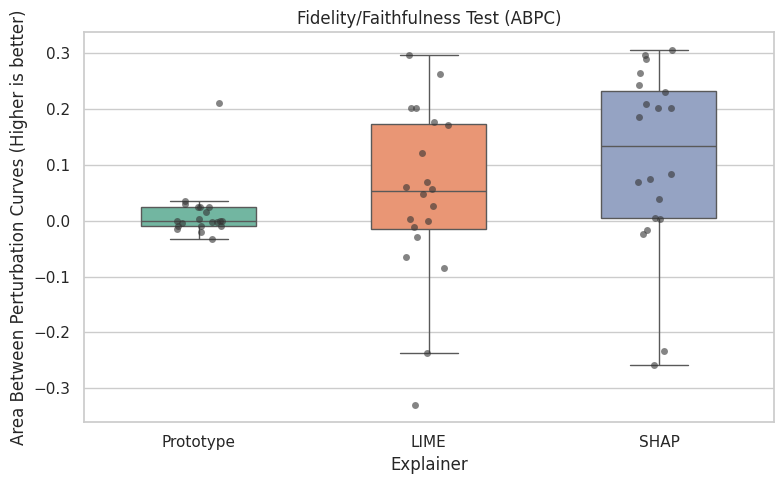

{'Prototype': [np.float64(0.024863486098718995),
  np.float64(0.002117463071518444),
  np.float64(-0.032366766659163604),
  np.float64(-0.00971993506370486),
  np.float64(0.02391934970393253),
  np.float64(0.029900926283161128),
  np.float64(3.660772090335884e-05),
  np.float64(-0.002474184108454097),
  np.float64(0.0),
  np.float64(0.21045730925038197),
  np.float64(0.024841316489795567),
  np.float64(0.03427255042369676),
  np.float64(-0.005246201835475223),
  np.float64(-0.009421087803955647),
  np.float64(0.014929925811315553),
  np.float64(-0.014412874447218893),
  np.float64(-0.00228108044355127),
  np.float64(8.326672684688674e-17),
  np.float64(-0.00978122748402796),
  np.float64(-0.020307327401351744)],
 'LIME': [np.float64(-0.08525900800958172),
  np.float64(0.20132878212657765),
  np.float64(0.11988087316291782),
  np.float64(0.04823072784282037),
  np.float64(0.026057137158892657),
  np.float64(-0.32866338069264267),
  np.float64(0.20151215962874158),
  np.float64(0.0687788

In [12]:
tester.fidelity_test(display=True)

### Causality test

/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a v

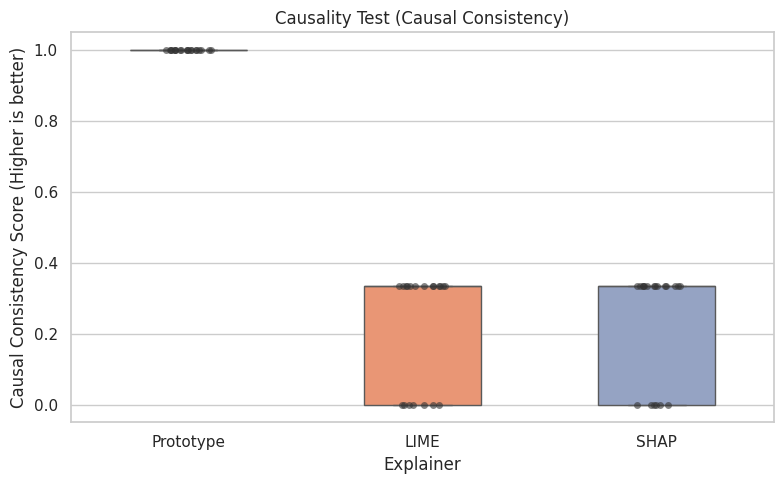

{'Prototype': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'LIME': [0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.0,
  0.0,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.0,
  0.3333333333333333,
  0.3333333333333333],
 'SHAP': [0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.0,
  0.3333333333333333]}

In [13]:
tester.causality_test(display=True)

### Decision utility test

/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/.local/lib/python3.10/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a v

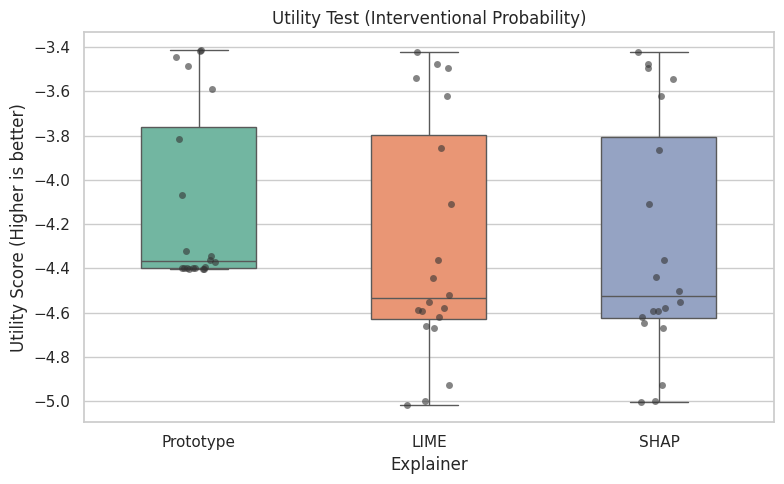

{'Prototype': [np.float64(-4.397459261300747),
  np.float64(-4.402666041308545),
  np.float64(-3.590548032126904),
  np.float64(-4.066989851764669),
  np.float64(-3.4839139367672507),
  np.float64(-4.398283571051504),
  np.float64(-4.399788811085953),
  np.float64(-3.4169918865119397),
  np.float64(-4.395683401292268),
  np.float64(-4.399025838492676),
  np.float64(-4.363944338780048),
  np.float64(-4.320674998335106),
  np.float64(-4.369377385124688),
  np.float64(-3.8162445817685517),
  np.float64(-4.400198532749812),
  np.float64(-3.413039409837513),
  np.float64(-4.401593126465812),
  np.float64(-4.403590380408382),
  np.float64(-4.342545887657154),
  np.float64(-3.4443248869967404)],
 'LIME': [np.float64(-5.015086013838291),
  np.float64(-4.585979345910127),
  np.float64(-3.621504696114414),
  np.float64(-4.108410168483083),
  np.float64(-3.5378823446812984),
  np.float64(-4.9255061211899775),
  np.float64(-4.5800822821440335),
  np.float64(-3.4203766039708148),
  np.float64(-4.67

In [14]:
tester.utility_test(display=True)

## Adult Income dataset

In [ ]:
X, y = shap.datasets.adult()

In [ ]:
X.columns

In [ ]:
adult_features = X.columns.to_list()

adult_actions = [
    'pursue_higher_education',
    'change_occupation',
    'adjust_working_hours',
    'make_investment'
]

adult_causal = CausalModel(features=adult_features, actions=adult_actions)

adult_causal.add_causal_edge('Age', 'Education-Num')
adult_causal.add_causal_edge('Age', 'Marital Status')
adult_causal.add_causal_edge('Age', 'Hours per week')

adult_causal.add_causal_edge('Country', 'Education-Num')
adult_causal.add_causal_edge('Race', 'Education-Num')
adult_causal.add_causal_edge('Sex', 'Occupation')

adult_causal.add_causal_edge('Education-Num', 'Occupation')
adult_causal.add_causal_edge('Education-Num', 'Workclass')

adult_causal.add_causal_edge('Marital Status', 'Relationship')

adult_causal.add_causal_edge('Occupation', 'Hours per week')
adult_causal.add_causal_edge('Occupation', 'Capital Gain')
adult_causal.add_causal_edge('Occupation', 'Capital Loss')

adult_causal.add_causal_edge('Race', 'Workclass')

adult_causal.add_causal_edge('Workclass', 'Hours per week')

adult_causal.add_causal_edge('Age', 'pursue_higher_education')
adult_causal.add_causal_edge('Education-Num', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital Gain', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital Loss', 'pursue_higher_education')

adult_causal.add_causal_edge('Occupation', 'change_occupation')
adult_causal.add_causal_edge('Education-Num', 'change_occupation')
adult_causal.add_causal_edge('Workclass', 'change_occupation')
adult_causal.add_causal_edge('Capital Gain', 'change_occupation')

adult_causal.add_causal_edge('Hours per week', 'adjust_working_hours')
adult_causal.add_causal_edge('Marital Status', 'adjust_working_hours')
adult_causal.add_causal_edge('Relationship', 'adjust_working_hours')

adult_causal.add_causal_edge('Capital Gain', 'make_investment')
adult_causal.add_causal_edge('Capital Loss', 'make_investment')
adult_causal.add_causal_edge('Education-Num', 'make_investment')

dag = adult_causal.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

## Diabetes dataset

In [ ]:
X, y = shap.datasets.california()
X

In [ ]:
y

## Iris dataset